## Problem Statement

Road traffic crashes remaain a significant public safety issue often resulting in severe injuries or fatalities. To efefctively reduce crash occurences and imporve safety outcomes, it is essential to understand the key fcators that contribute to crash severity and frequency. This analysis aims to explore this large-scale traffic crash dataset to answer critical questions. By addressing these questions, the analysis will help identify high-risk conditions, beahviors and regions, enabling data-driven interventions and policy recommendations aimed at improving road safety and reducing crash-related injuries and fatalities. 

## Analysis Objectives

1. Identify and analyse key risk factors contributing to crash severity.
2. Examine temporal and situational patterns in crash and injury severity.
3. Evaluate the impact of preventive measures on crash outcomes.

## Business Understanding

This project analyses road traffic crash data to help public safety agencies and policymakers enhance road safety by addressing three objectives. These insights will support targeted interventions, efficienta resource allocation and data-driven policies to reduce crash frequency and severity. 

## Business Questions

1. Which factors are most associated with severe or fatal injuries?
2. When and where do serious crashes most frequently occur and how do injury patterns vary?
3. How do safety measures impact crash frequency and injury severity? 

## Data Understanding

Datasets: 

- [cpd-traffic-crashes](https://data.cityofchicago.org/Transportation/Traffic-Crashes-Crashes/85ca-t3if/about_data)
Crash data shows information about each traffic crash on city streets within the City of Chicago limits and under the jurisdiction of Chicago Police Department (CPD). 
- [cpd-traffic-crashes-people](https://data.cityofchicago.org/Transportation/Traffic-Crashes-People/u6pd-qa9d/about_data)
This data containes information about people involved in a crash and if any injuries were sustained.
- [cpd-traffic-crashes-vehicles](https://data.cityofchicago.org/Transportation/Traffic-Crashes-Vehicles/68nd-jvt3/about_data)
This dataset contains information about vehicles (or units as they are identified in crash reports) involved in a traffic crash. 

The three datasets were utilized to gain a comprehensive understanding of cash data involving both individuals and vehicles. The datasets were merged into a single DataFrame containing records and features, forming the basis for subsequent data preprocessing and cleaning. 

The focus of the analysis is on the features of the cleaned DataFrame, which are outlines as follows:

`'CRASH_RECORD_ID'`,
`'CRASH_DATE'`, 
`'POSTED_SPEED_LIMIT'`,
`'TRAFFIC_CONTROL_DEVICE'`, 
`'DEVICE_CONDITION'`,
`'WEATHER_CONDITION'`,
`'LIGHTING_CONDITION'`, 
`'CRASH_TYPE'`,
`'TRAFFICWAY_TYPE'`,
`'DAMAGE'`,
`'ALIGNMENT'`,
`'ROADWAY_SURFACE_COND'`, 
`'NUM_UNITS'`,
`'MOST_SEVERE_INJURY'`, 
`'INJURIES_TOTAL'` ,
`'INJURIES_FATAL'`,
`'INJURIES_INCAPACITATING'`,
`'INJURIES_NON_INCAPACITATING'`,
`'INJURIES_REPORTED_NOT_EVIDENT'`,
`'INJURIES_NO_INDICATION'`,
`'INJURIES_UNKNOWN'`,
`'CRASH_HOUR'`,
`'CRASH_DAY_OF_WEEK'`, 
`'CRASH_MONTH'`,
`'PERSON_ID'`,
`'PERSON_TYPE'`, 
`'VEHICLE_ID'`,
`'CITY'`,
`'STATE'`, 
`'SEX'`,
`'AGE'`,
`'SAFETY_EQUIPMENT'`, 
`'AIRBAG_DEPLOYED'`,
`'INJURY_CLASSIFICATION'`, 
`'PHYSICAL_CONDITION'`,
`'CRASH_UNIT_ID'`,
`'UNIT_NO'`,
`'UNIT_TYPE'`, 
`'MAKE'`,
`'MODEL'`,
`'VEHICLE_YEAR'`,
`'VEHICLE_DEFECT'`, 
`'VEHICLE_TYPE'`,
`'VEHICLE_USE'`,
`'OCCUPANT_CNT'`, 
`'AGE_missing'`,
`'CRASH_TYPE_GROUP'`

## Data Preprocessing

### Importing Necessary Libraries

In [1]:
# Importing data manipulation libraries
import pandas as pd
import numpy as np
# Importing data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Importing machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
# Importing libraries for model interpretability
import lime
import lime.lime_tabular
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore") 

In [2]:
# Importing the class 
from utils import CrashDataProcessor

### Loading and Merging the Datasets

In [3]:
processor = CrashDataProcessor(
    crashes_path="data\cpd-traffic-crashes-crashes.csv",
    people_path="data\cpd-traffic-crashes-people.csv",
    vehicles_path="data\cpd-trafiic-crashes-vehicles.csv"
)

# Loading and merging the data
processor.load_and_merge()

### Inspecting Missing Values

In [4]:
processor.inspect_missing_values()


Shape of DataFrame: 4,438,390 rows * 44 columns

Missing Value Counts (non-zero only):
AGE                              1283184
CITY                             1203129
STATE                            1152255
PHYSICAL_CONDITION                914767
VEHICLE_YEAR                      683474
MODEL                             106483
MAKE                              106098
OCCUPANT_CNT                      106086
VEHICLE_USE                       106086
VEHICLE_TYPE                      106086
VEHICLE_DEFECT                    106086
VEHICLE_ID                         98235
AIRBAG_DEPLOYED                    93953
SEX                                80014
SAFETY_EQUIPMENT                   16971
INJURY_CLASSIFICATION               5395
UNIT_TYPE                           4462
MOST_SEVERE_INJURY                  3522
PERSON_TYPE                         3495
PERSON_ID                           3495
INJURIES_NO_INDICATION              3495
INJURIES_REPORTED_NOT_EVIDENT       3495
INJURIES_N

### Visualizing column distribution to find missing values, NANs and unknowns

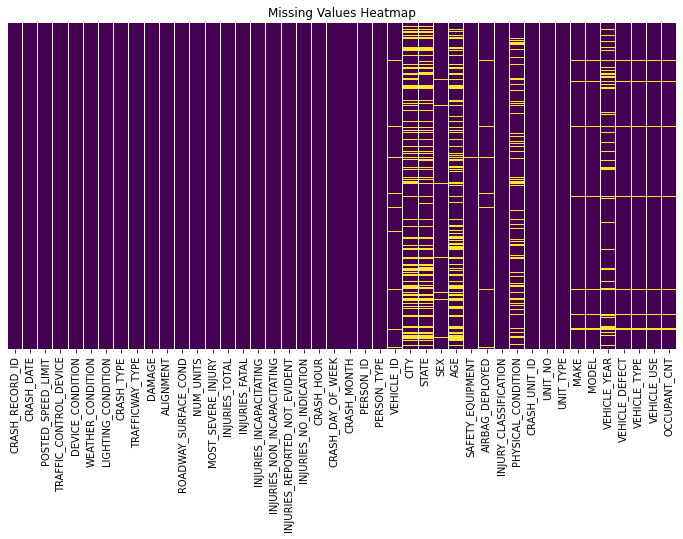

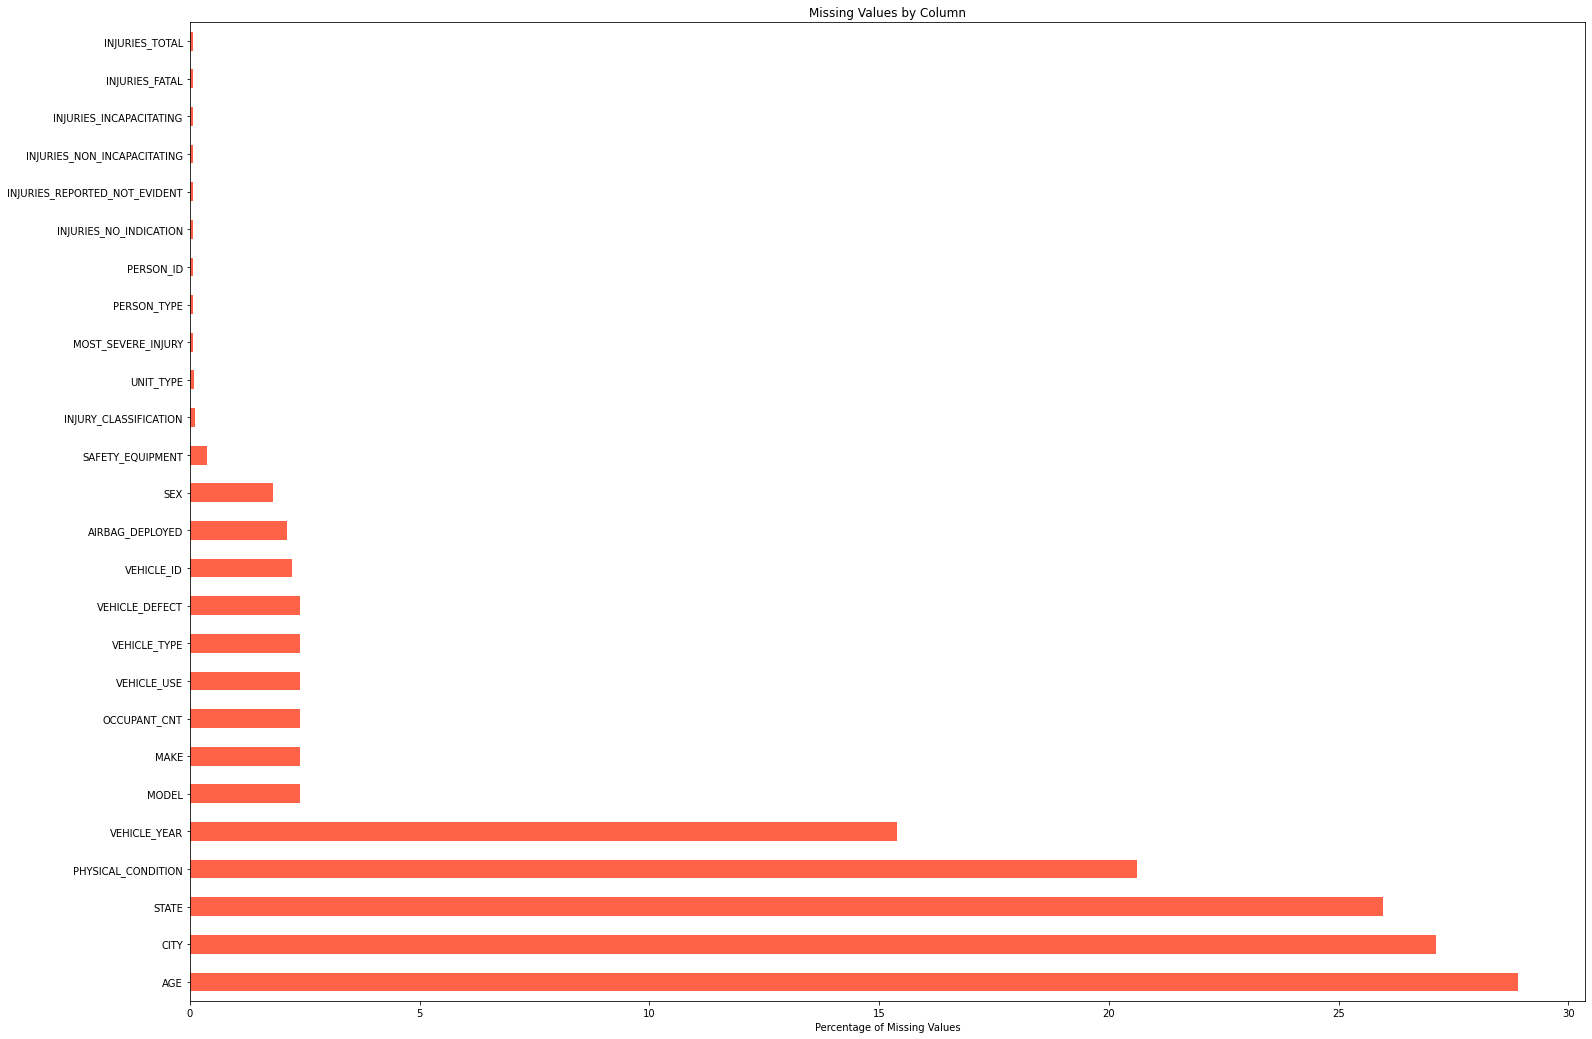

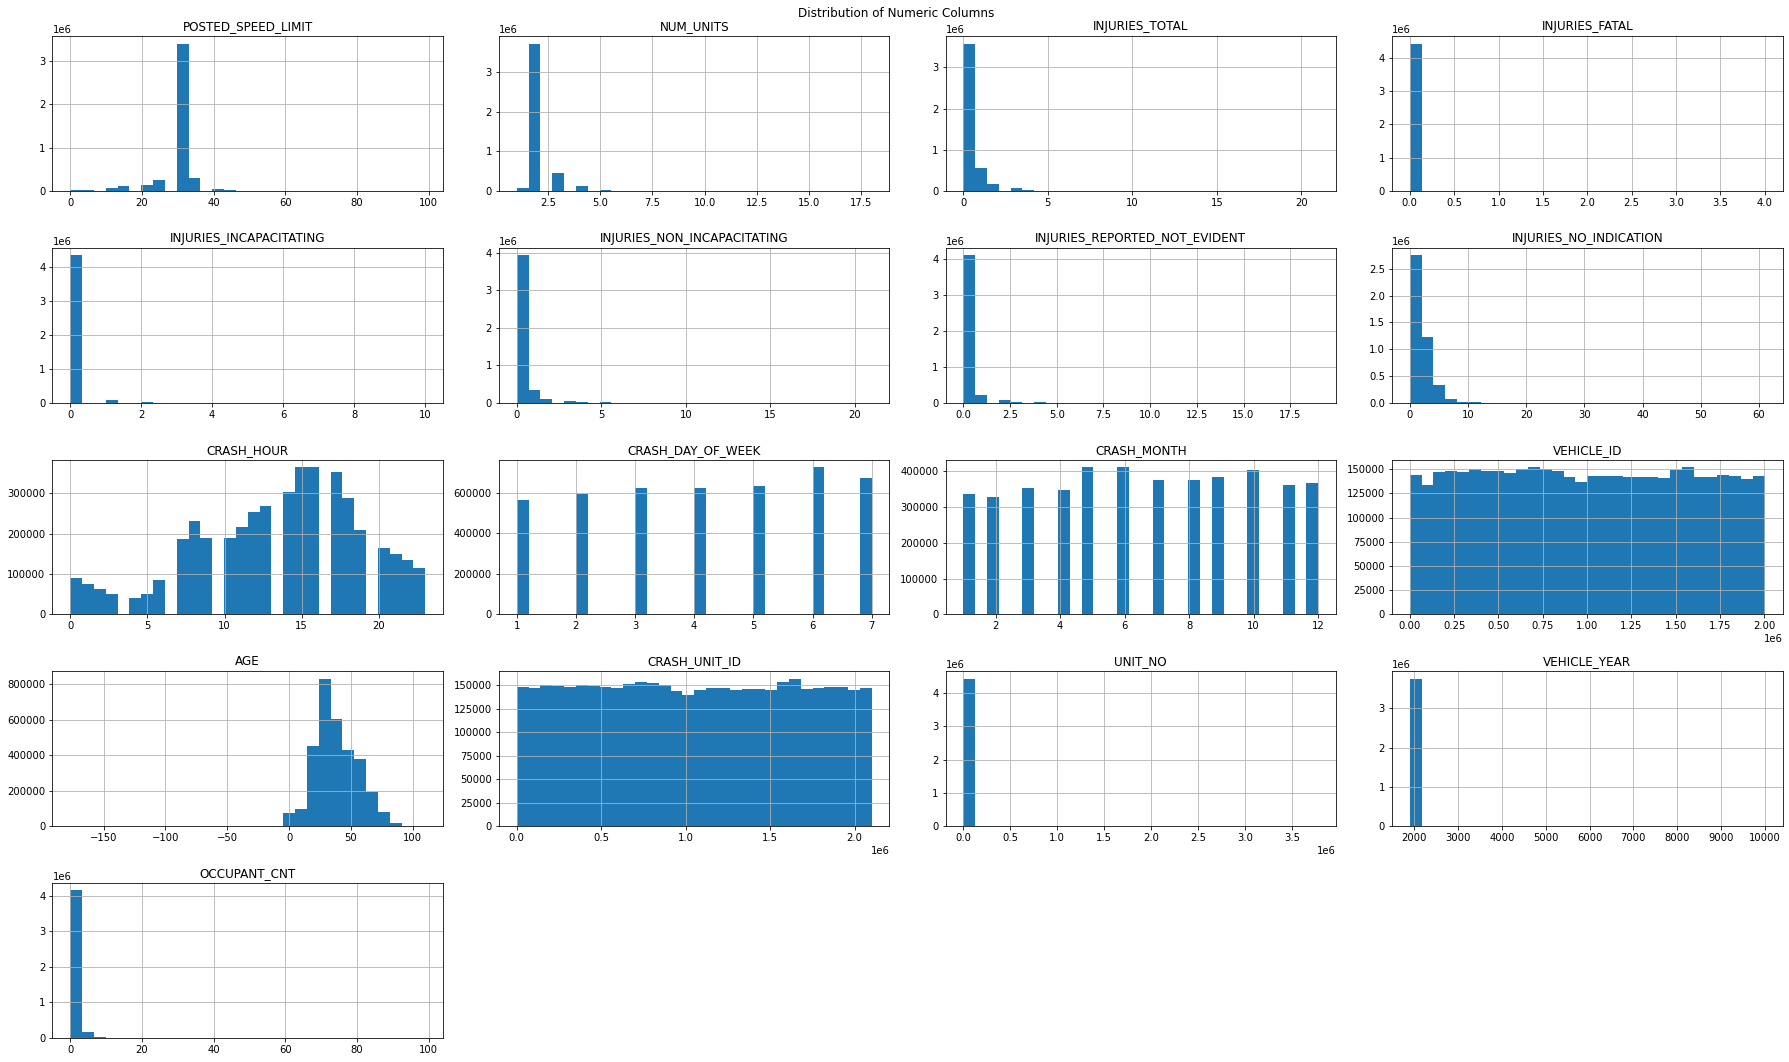

In [5]:
processor.visualize_missing_values_distributions()

The heatmap visually highlights missing data in the `df_merged` DataFrame, where light areas indicate missing values and dark areas represent complete data. Columns with large light sections have high missingness and may need imputation or removal, while mostly dark columns are largely complete. This helps quickly identify which features have data quality issues and whether missingness is random or systematic.

The bar graph shows the percentage of missing values per column in the `df_merged` DataFrame. Longer bars indicate higher missingness, with columns near 100% likely unsuitable for analysis, while shorter bars suggest more complete and reliable data. This helps quickly assess data completeness and identify features that may need cleaning or removal.

Histograms show the distribution of values for each numeric column in `df_merged`, where peaks indicate common values and gaps or skewness reveal outliers or irregular patterns. Single prominent bars may suggest low variance or many missing values. These plots help identify data quality issues, outliers, and understand typical value ranges.

### Data Cleaning

In [6]:
processor.clean_data()

Data cleaned. No remaining missing values.


In [7]:
# Assigning cleaned dataframe to df_clean to be easily accessible
df_clean = processor.df
# Calling first 5 rows
df_clean.head()

,CRASH_RECORD_ID,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,CRASH_TYPE,TRAFFICWAY_TYPE,DAMAGE,...,CRASH_UNIT_ID,UNIT_NO,UNIT_TYPE,MAKE,MODEL,VEHICLE_YEAR,VEHICLE_DEFECT,VEHICLE_TYPE,VEHICLE_USE,OCCUPANT_CNT
2,000c4307d8e9b39075cffdd0aade3603e0f96f14e41da9...,01/14/2025 12:25:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,NO INJURY / DRIVE AWAY,DIVIDED - W/MEDIAN (NOT RAISED),"$501 - $1,500",...,1986728,1,DRIVER,JEEP,COMPASS,2023.0,NONE,PASSENGER,PERSONAL,1.0
3,000c4307d8e9b39075cffdd0aade3603e0f96f14e41da9...,01/14/2025 12:25:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,NO INJURY / DRIVE AWAY,DIVIDED - W/MEDIAN (NOT RAISED),"$501 - $1,500",...,1986729,2,DRIVER,AUDI,A4,2011.0,NONE,PASSENGER,PERSONAL,1.0
10,0b5603954d84b7341c7cad4f570ea039e85919f3750ccb...,05/23/2025 09:15:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,INJURY AND / OR TOW DUE TO CRASH,NOT DIVIDED,$500 OR LESS,...,2069029,1,DRIVER,TOYOTA,RAV4,2016.0,UNKNOWN,PASSENGER,PERSONAL,2.0
16,00bce77960c2faa2a8782a8cac1d6e5715802d6c072a08...,01/14/2025 08:00:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,NO INJURY / DRIVE AWAY,FOUR WAY,"OVER $1,500",...,1986537,1,DRIVER,NISSAN,PATHFINDER,2023.0,UNKNOWN,PASSENGER,UNKNOWN/NA,1.0
17,00bce77960c2faa2a8782a8cac1d6e5715802d6c072a08...,01/14/2025 08:00:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,NO INJURY / DRIVE AWAY,FOUR WAY,"OVER $1,500",...,1986538,2,DRIVER,FORD,ESCAPE,2018.0,NONE,PASSENGER,PERSONAL,1.0


In [8]:
# Getting summary statistics of the dataframe
df_clean.describe()

,POSTED_SPEED_LIMIT,NUM_UNITS,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,VEHICLE_ID,AGE,CRASH_UNIT_ID,UNIT_NO,VEHICLE_YEAR,OCCUPANT_CNT
count,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06,2.003969e+06
mean,2.913918e+01,2.203247e+00,2.891841e-01,1.384253e-03,2.550489e-02,1.579945e-01,1.043005e-01,2.375505e+00,1.334959e+01,4.151573e+00,6.609769e+00,9.802270e+05,3.998947e+01,1.029520e+06,1.615118e+00,2.013147e+03,1.234056e+00
std,5.383787e+00,6.600640e-01,7.641989e-01,4.175668e-02,2.019525e-01,5.605389e-01,4.355479e-01,1.320748e+00,5.260703e+00,1.948159e+00,3.397434e+00,5.772054e+05,1.577074e+01,6.075392e+05,6.765144e-01,9.321254e+01,7.961858e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,1.900000e+03,0.000000e+00
25%,3.000000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+01,2.000000e+00,4.000000e+00,4.809990e+05,2.700000e+01,5.031450e+05,1.000000e+00,2.007000e+03,1.000000e+00
50%,3.000000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.400000e+01,4.000000e+00,7.000000e+00,9.555440e+05,3.700000e+01,1.008227e+06,2.000000e+00,2.013000e+03,1.000000e+00
75%,3.000000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,1.700000e+01,6.000000e+00,1.000000e+01,1.483855e+06,5.100000e+01,1.559974e+06,2.000000e+00,2.017000e+03,1.000000e+00
max,9.900000e+01,1.800000e+01,2.100000e+01,4.000000e+00,1.000000e+01,2.100000e+01,1.900000e+01,6.100000e+01,2.300000e+01,7.000000e+00,1.200000e+01,2.003440e+06,9.500000e+01,2.101549e+06,1.800000e+01,9.999000e+03,6.000000e+01


## Exploratory Data Analysis

EDA helps us understand the structure, quality and patter in the crash data. It involves visualizing distributions and exploring relationships between variables to prepare the data for meaningful analyses and insights. 

### Objective 1: Identify and Analyze Key Risk Factors Contributing to Crash Severity

Performing a univariate analysis to visualize the distribution of the target variable. 

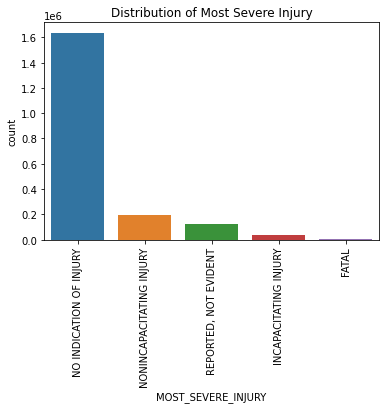

In [12]:
# Target variable distribution 
sns.countplot(x="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Distribution of Most Severe Injury")
plt.xticks(rotation=90)
plt.show(); 

The above chart highlights the frequency of each injury type, showing which outcomes are most common. The taller bars like "NO INDICATION OF INJURY" suggest that most crashes lead to minor injury while shorter bars for "INCAPACITATING INJURY" or "FATAL" indicate that there are rarer, severe cases on most occassion of a crash. 

A grouped bar chart to explore the relationship between safety equipment usage and the severity of injuries in traffic crashes. 

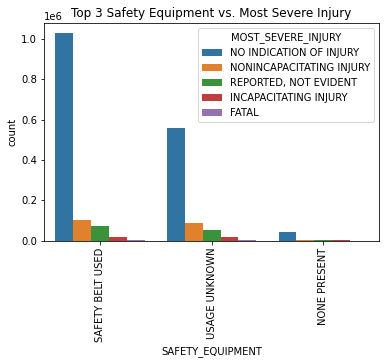

In [15]:
# Safety equipment vs. severity
sns.countplot(x="SAFETY_EQUIPMENT",
              hue="MOST_SEVERE_INJURY",
              data=df_clean[df_clean["SAFETY_EQUIPMENT"].isin(
                  df_clean["SAFETY_EQUIPMENT"].value_counts().nlargest(3).index
                )]
            )
plt.title("Top 3 Safety Equipment vs. Most Severe Injury")
plt.xticks(rotation=90)
plt.show(); 

In the visualization above, there was mostly no indication of injury for those who used a safety belt.

Boxplot comparing the distribution of ages across different injury severity levels.

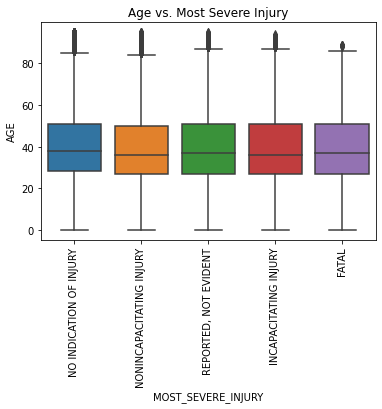

In [ ]:
# Age vs severity of injury
sns.boxplot(x="MOST_SEVERE_INJURY", y="AGE", data=df_clean)
plt.title("Age vs. Most Severe Injury")
plt.xticks(rotation=90)
plt.show(); 

The median age tends to be higher for no indication of injury and slightly lower for incapacitating injury and fatal injuries. Younger individuals appear more in the categories of incapacitating and fatal which suggest age may influence injury severity. 

The heatmap displays the pairwise correlation between key numerical features related to crashes and injuries.

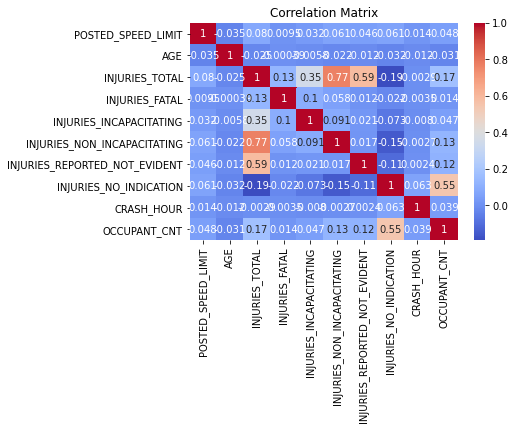

In [17]:
# Correlation analysis in the numerical features
numerical_cols = [
    'POSTED_SPEED_LIMIT', 'AGE', 'INJURIES_TOTAL', 'INJURIES_FATAL',
    'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING',
    'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 
    'CRASH_HOUR', 'OCCUPANT_CNT'
]
corr = df_clean[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show(); 

Strong positive correlations exis between total injuries and specific injury types for example fatal and incapacitating indicating they move together. Features like age and posted speed limit show weak correlations with injury outcomes suggesting other factors may play a larger role in severity.

The stacked bar chart shows the proportion of injury severities across different weather conditions.

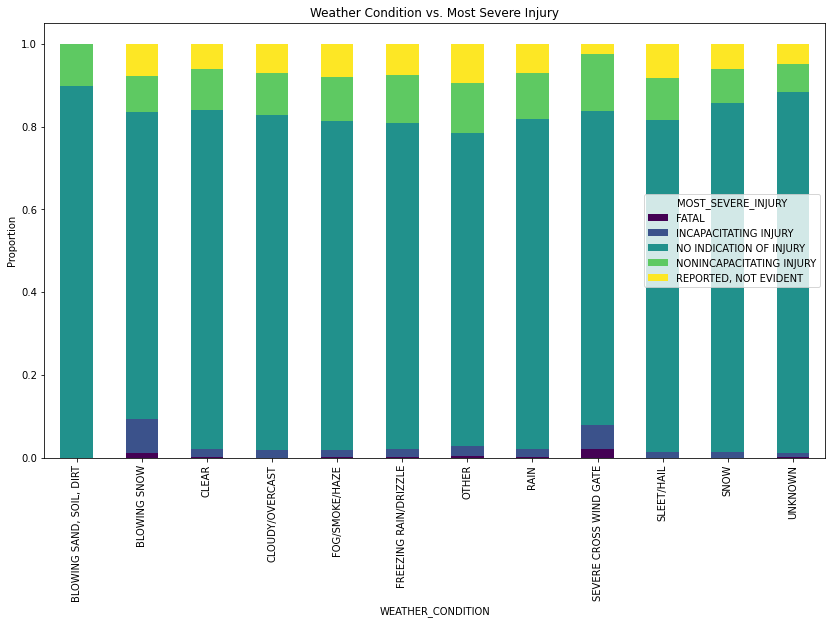

In [19]:
# Crosstab and stacked bar chart for categorical association
pd.crosstab(df_clean["WEATHER_CONDITION"], df_clean["MOST_SEVERE_INJURY"], normalize="index").plot(
    kind="bar", stacked=True, colormap="viridis", figsize=(14,8)
)
plt.title("Weather Condition vs. Most Severe Injury")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.show(); 

Most crashes across all weather conditions result in minor or no injuries. Severe injuries appear slightly more common in adverse conditions including snow and windy conditions. This suggests weather may influence injury severity. 

The histogram below illustrates the age distribution of individuals involved in crashes, colored by the injury severity.

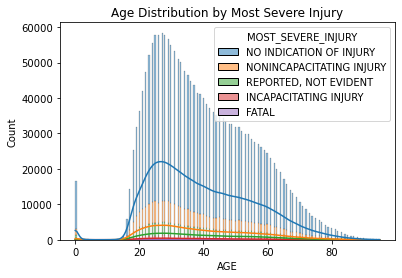

In [21]:
# Age distribution by most severe injury
sns.histplot(data=df_clean, x="AGE", hue="MOST_SEVERE_INJURY", kde=True, multiple="stack")
plt.title("Age Distribution by Most Severe Injury")
plt.show(); 

Most crash-involved individuals fall withing the young to middle-age range of arund 20-40 years. Less severe injuries dominate across all ages while severe outcomes appear more frequently at younger and older age extremes.

This stacked bar chart shows the projection of injury severities under different weather conditions.

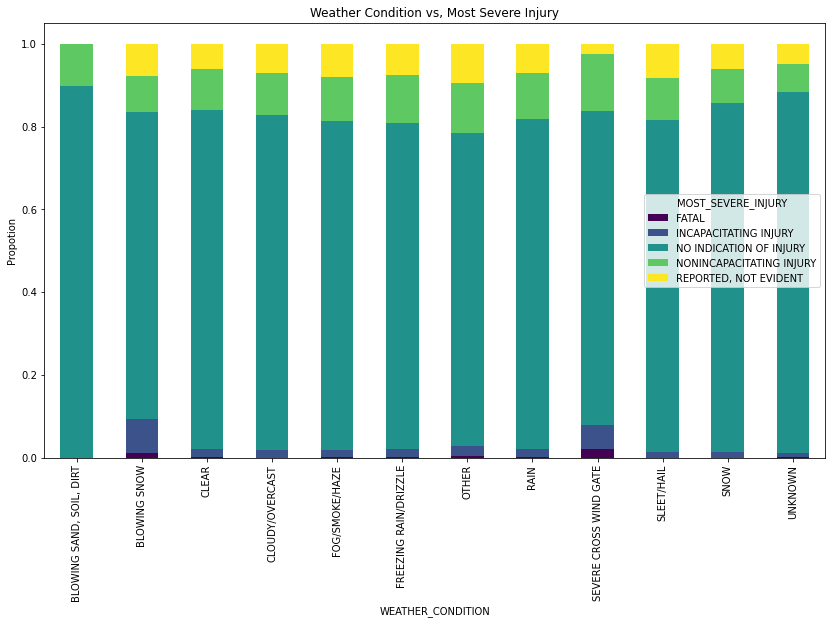

In [24]:
# Injury severity in different weather condition
pd.crosstab(df_clean["WEATHER_CONDITION"], df_clean["MOST_SEVERE_INJURY"], normalize="index").plot(
    kind="bar", stacked=True, colormap="viridis", figsize=(14,8))
plt.title("Weather Condition vs, Most Severe Injury")
plt.ylabel("Propotion")
plt.xticks(rotation=90)
plt.show(); 

The stacked bar chart shows that most crashes regardless of weather conditions, result in minor or no injuries. However, severe injuries are slightly more common during weather conditions like blowing snow and severe cross winds. 

The stacked bar chart below illustrates the proportion of injury severities across different roadway surface conditions.

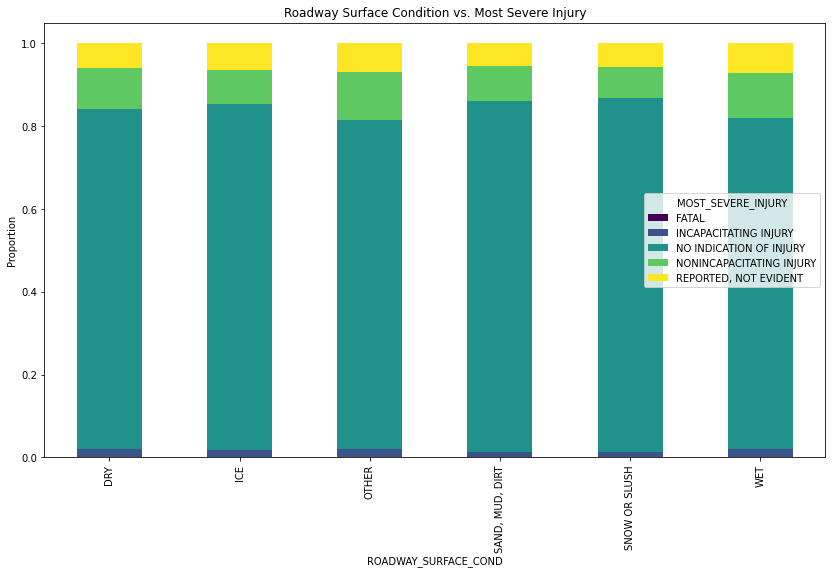

In [26]:
# Injury severity in different roadway surface condition
pd.crosstab(df_clean["ROADWAY_SURFACE_COND"], df_clean["MOST_SEVERE_INJURY"], normalize="index").plot(
    kind="bar", stacked=True, colormap="viridis", figsize=(14,8))
plt.title("Roadway Surface Condition vs. Most Severe Injury")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.show(); 

The road conditions account for fairly the same proportion of accidents all across. 

The heatmap show how total injuries are distributed across different ages. 

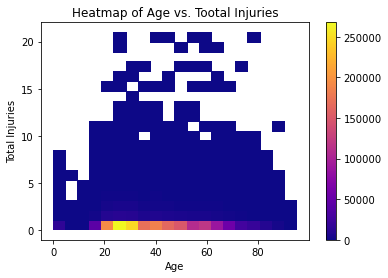

In [32]:
# Total injuries distributed across different ages
sns.histplot(data=df_clean, x="AGE", y="INJURIES_TOTAL", bins=20, cmap="plasma", cbar=True)
plt.title("Heatmap of Age vs. Tootal Injuries")
plt.xlabel("Age")
plt.ylabel("Total Injuries")
plt.show(); 

Most crashes with injuries occur among people aged roughly 20-40, with low to moderate injury counts being most common. High injury counts are rare and scattered across all age groups. 

The bar chart compares the distribution of injury severity across different sexes involved in crashes.

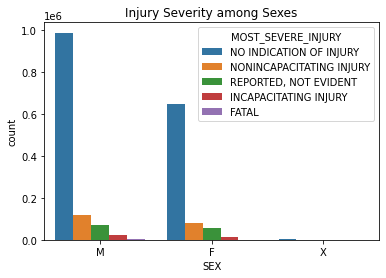

In [33]:
# Injury severity across different sexes
sns.countplot(x="SEX", hue="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Injury Severity among Sexes")
plt.show(); 

Both males and females are most often involved in crashes resulting in no indication of injury or non-incapacitating injuries. However, males appear to have a slightly higher count in severe categories such as fatal and incapacitating injuries compared to females.

The boxplot shows the distribution of posted speed limits across different levels of injury severity. 

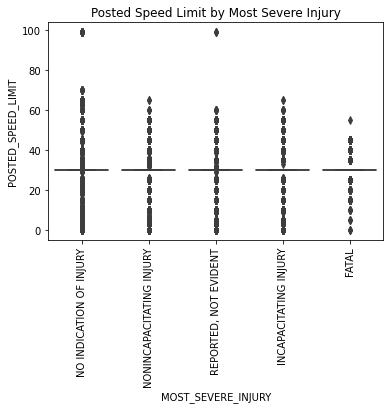

In [37]:
sns.boxplot(x="MOST_SEVERE_INJURY", y="POSTED_SPEED_LIMIT", data=df_clean)
plt.title("Posted Speed Limit by Most Severe Injury")
plt.xticks(rotation=90)
plt.show(); 

Most severe injuries occur across a wide range of speed limits but fatal and incapacitating injuries tend to cluster at higher speed zones. Less severe injuires are more common clustered around moderate or low speed limits suggesting speed may play a role in injury severity. 

The bar chart below compares the top three most common vehicle types against injury severity outcomes in crashes. 

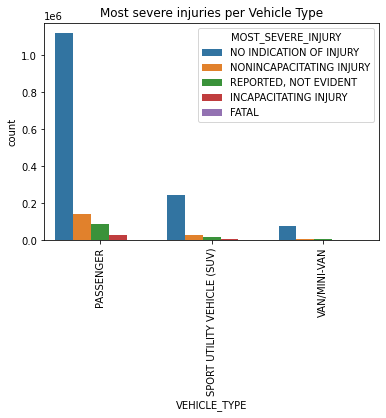

In [ ]:
# Top three common vehicle types against injury severity
top_types = df_clean["VEHICLE_TYPE"].value_counts().head(3).index
sns.countplot(x="VEHICLE_TYPE", hue="MOST_SEVERE_INJURY", data=df_clean[df_clean["VEHICLE_TYPE"].isin(top_types)])
plt.title("Most severe injuries per Vehicle Type")
plt.xticks(rotation=90)
plt.show(); 

Passenger vehicles are the most involved in all injury categories likely due to their higher frequency on the road. SUVs show slightly higher proportions of severe injuries. 

The bar chart below compares injury severity outcomes between single-vehicle and multi-vehicle crashes. The analysis was derived from the `NUM_UNITS` column where 1 was a single vehicles and >1 meant multi vehicle crashes.

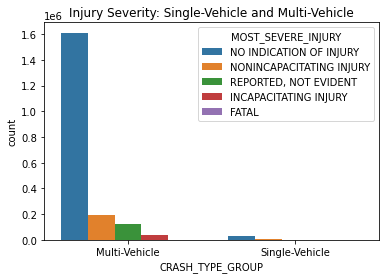

In [40]:
# Injury severity against single or multi-vehicles crashes 
df_clean["CRASH_TYPE_GROUP"] = df_clean["NUM_UNITS"].apply(lambda x: "Single-Vehicle" if x == 1 else "Multi-Vehicle")
sns.countplot(x="CRASH_TYPE_GROUP", hue="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Injury Severity: Single-Vehicle and Multi-Vehicle")
plt.show(); 

Multi-vehicle crashes are more frequent and result in a wider range of injury severities including many non-severe cases. 

### Objective 2: Examine Temporal and Situational Patterns in Crash and Injury Severity

This countplot displays the number of crashes per hour of the day categorized by injury severity.

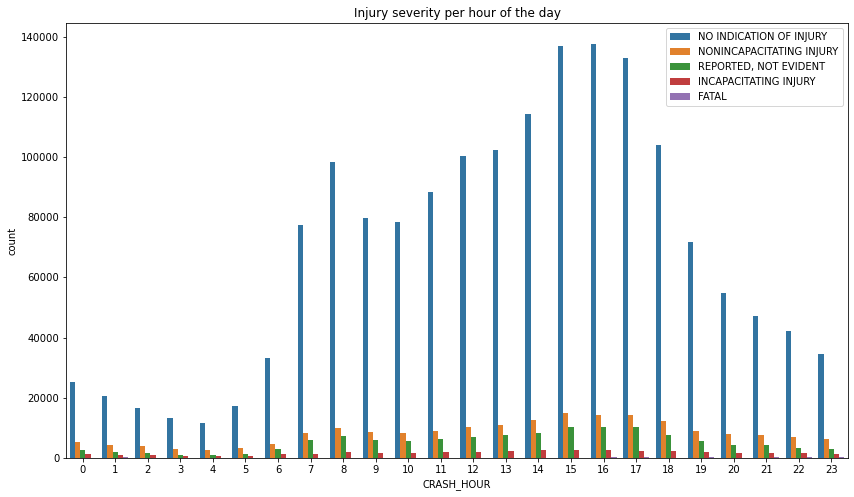

In [53]:
# Injury severity per hour of the day
plt.figure(figsize=(14,8))
sns.countplot(x="CRASH_HOUR", hue="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Injury severity per hour of the day")
plt.legend()
plt.show(); 

Crash frequency peaks during the morning rush hours and in the afternoon rush hours which are typically commute hours. Most injuries are mionr, but severe injuries occur steadily throughout the day suggesting rsk exists beyond peak traffic times.

The line plot shows the total number of crashes that occured during each hour of the day.

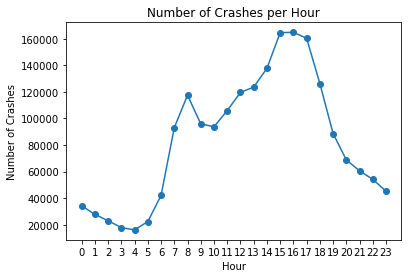

In [48]:
# Total number of crashes by hour of the day
hourly_counts = df_clean.groupby("CRASH_HOUR")["CRASH_RECORD_ID"].count().sort_index()
plt.plot(hourly_counts.index, hourly_counts.values, marker="o")
plt.title("Number of Crashes per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Crashes")
plt.xticks(hourly_counts.index)
plt.show(); 

Crash counts rise sharply during typical rush hours with noticeable peaks around 8am and 5pm. This pattern highlights the impact of daily commute times on crash frequency. 

The countplot below displayes crash counts across days of the week segmented by injury severity. 

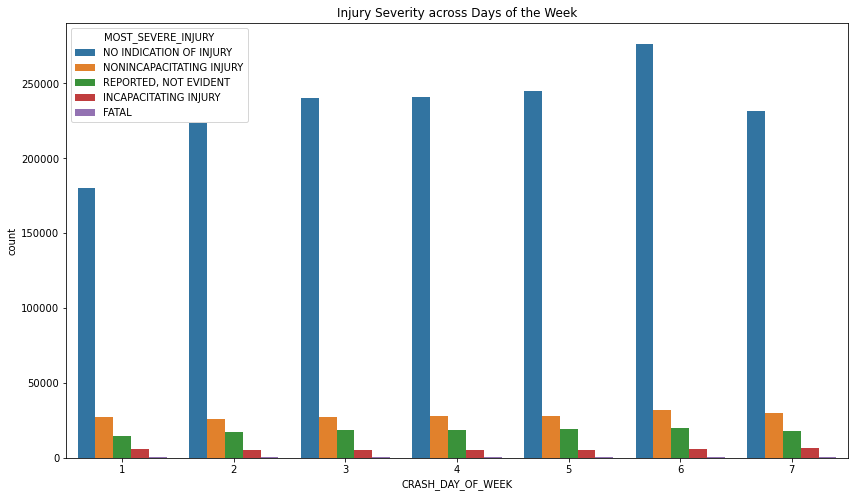

In [ ]:
# Injury severity across days of the week
plt.figure(figsize=(14,8))
sns.countplot(x="CRASH_DAY_OF_WEEK", hue="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Injury Severity across Days of the Week")
plt.show(); 

Crashes are most frequent on Fridays and least common on Sundays reflecting weekday traffic volumes. Most injuries are minor but severe injuries remain relatively consistent throughout the week.

The heatmap below visualizes crash frequency across days of the week and hours of the day.

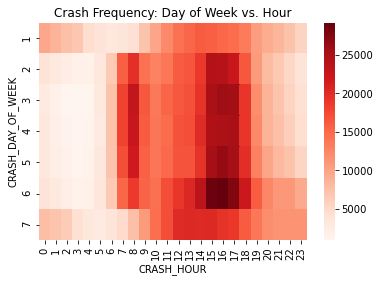

In [56]:
pivot = df_clean.pivot_table(index="CRASH_DAY_OF_WEEK", columns="CRASH_HOUR", values="CRASH_RECORD_ID", aggfunc="count")
sns.heatmap(pivot, cmap="Reds")
plt.title("Crash Frequency: Day of Week vs. Hour")
plt.show(); 

Crashes are most frequent during weekday rush hours especially between 7am to 8am and 3pm to 5pm. Weekends show fewer crashes overall with less pronounced hourly peaks, reflecting reduced commuter traffic. 

The following countplot shows the distribution of crashes and injury severities across each month of the year. 

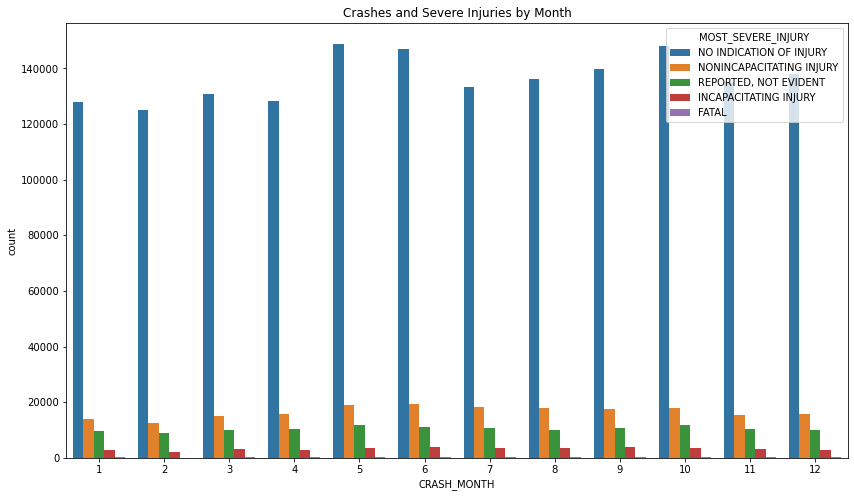

In [57]:
# Distribution of crashes and injury severities across each month
plt.figure(figsize=(14,8))
sns.countplot(x="CRASH_MONTH", hue="MOST_SEVERE_INJURY", data=df_clean)
plt.title("Crashes and Severe Injuries by Month")
plt.show(); 

Crash frequency remains fairly consistent throughout the year with slight peaks in warmer months like May and July. Severe injuries are relatively stable across months suggesting seasonality has limited influence on injury severity. 

The following line plot shows the total number of crashes recorded in each month throughtout the year.

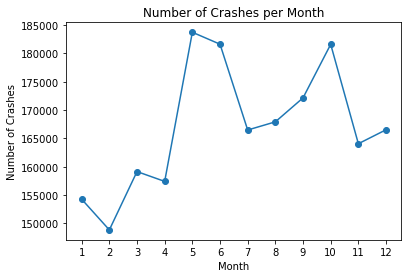

In [58]:
# Crashes recorded in each month throughout the year
monthly_counts = df_clean.groupby("CRASH_MONTH")["CRASH_RECORD_ID"].count().sort_index()
plt.plot(monthly_counts.index, monthly_counts.values, marker="o")
plt.title("Number of Crashes per Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")
plt.xticks(monthly_counts.index)
plt.show(); 

Crashes appear relatively steady across months with modest increases in spring and summer particularly May, June and October as well. These trends may reflect seasonal factors like increased travel or more vehicles on the road during warmer periods.

The following line plot displays the monthly count of crashes that resulted in severe injuries or fatalities.

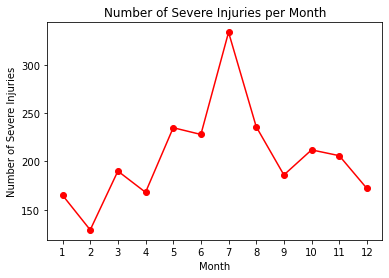

In [59]:
# Severe injuries by the month
severe = df_clean[df_clean['MOST_SEVERE_INJURY'].isin(['FATAL', 'INCAPACITATING'])]
severe_monthly = severe.groupby('CRASH_MONTH')['CRASH_RECORD_ID'].count().sort_index()
plt.plot(severe_monthly.index, severe_monthly.values, marker='o', color='red')
plt.title('Number of Severe Injuries per Month')
plt.xlabel('Month')
plt.ylabel('Number of Severe Injuries')
plt.xticks(severe_monthly.index)
plt.show(); 

Severe injuries are relatively low in number but show slight increases in March and warmer months like July.

### Objective 3: Evaluate the Impact of Preventive Measures on Crash Outcomes

The following stacked bar chart compares injury severity proportions for the five most frequent used types of safety equipment.

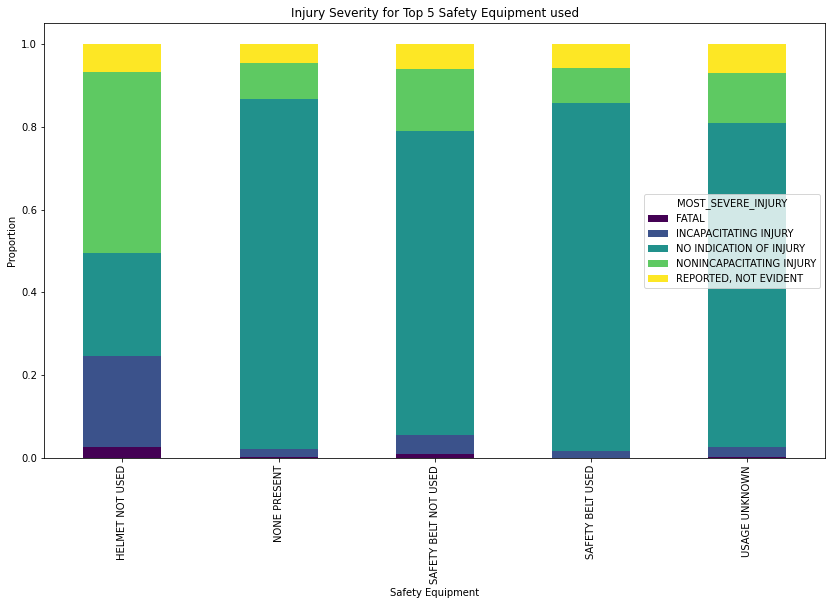

In [60]:
# Injury severity for five most used safety equipment
pd.crosstab(
    df_clean[df_clean['SAFETY_EQUIPMENT'].isin(
        df_clean['SAFETY_EQUIPMENT'].value_counts().head(5).index
    )]['SAFETY_EQUIPMENT'],
    df_clean[df_clean['SAFETY_EQUIPMENT'].isin(
        df_clean['SAFETY_EQUIPMENT'].value_counts().head(5).index
    )]['MOST_SEVERE_INJURY'],
    normalize='index'
).plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    figsize=(14, 8)
)
plt.title("Injury Severity for Top 5 Safety Equipment used")
plt.xlabel("Safety Equipment")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.show(); 

The stacked bar chart compares injury severity proportions for the five most frequently used types of safety equipment. Most individuals using safety belts experience minor or no injuries, while less common equipment types show higher proportions of severe injuries. This highlights the effectiveness of safety belts in reducing injury severity during crashes.

The following bar chart displays the most common traffic control devices present at crash scenes.

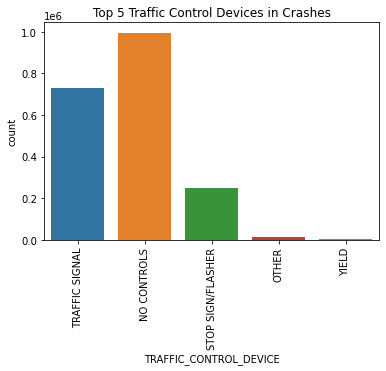

In [61]:
# Frequency of traffic control devices at crash scenes
top_devices = df_clean["TRAFFIC_CONTROL_DEVICE"].value_counts().head().index
sns.countplot(x="TRAFFIC_CONTROL_DEVICE", data=df_clean[df_clean["TRAFFIC_CONTROL_DEVICE"].isin(top_devices)])
plt.title("Top 5 Traffic Control Devices in Crashes")
plt.xticks(rotation=90)
plt.show(); 

The bar chart displays the five most common traffic control devices present at crash scenes, with "NO CONTROLS" and "TRAFFIC SIGNAL" being the most frequent. This highlights intersections and uncontrolled areas as key locations for crash occurrences.

## Modelling

### Modelling Objective: Build and evaluate predictive models to classify or predict injury severity based on available features